In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import traceback
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: bird


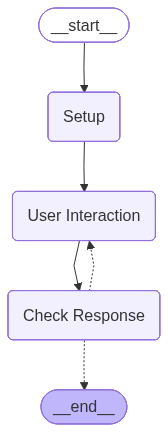

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
# bird_error_exps = ["6", "14", "24", "33", "34", "43"]
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # if database == "bird":
        
    #     if exp_id in bird_error_exps:
    #         continue
    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    try:
        # Invoca a avaliação
        eval_result = eval_graph.invoke(
            {
                "experiment": experiment,
                "max_retries": 2,
                "debug_mode": True,
                "model_version": model_version,
                "experiment_type": experiment_type,
            },
            {"recursion_limit": 200}
        )

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Salva resultado
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get(
                "experiment_config",
                {
                    "max_retries": 2,
                    "model_version": model_version,
                    "timestamp": datetime.now().isoformat(),
                    "experiment_type": experiment_type,
                }
            ),
            "experiment_eval": eval_result["experiment_eval"]
        })

    except Exception as e:
        print(f"\n Erro ao processar experimento {exp_id}: {e}")
        traceback.print_exc()

        # (Opcional) registra falha no arquivo de saída
        # evals.append({
        #     "experiment_id": exp_id,
        #     "experiment_config": {
        #         "model_version": model_version,
        #         "timestamp": datetime.now().isoformat(),
        #         "experiment_type": experiment_type,
        #     },
        #     "experiment_eval": None,
        #     "error": str(e)
        # })

    finally:
        # Atualiza o arquivo SEMPRE (sucesso ou erro)
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you tell me the races held in circuits located in Spain?


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "List all races that were held in circuits located in Spain.",
    "schema_linking": ["formula_1_races", "formula_1_circuits"],
    "answer": "Here are some of the races held in circuits located in Spain:\n\n1. Spanish Grand Prix (2009, Montmeló)\n2. European Grand Prix (2009, Valencia)\n3. Spanish Grand Prix (2008, Montmeló)\n4. European Grand Prix (2008, Valencia)\n5. Spanish Grand Prix (2007, Montmeló)\n\nFor a complete list of races, please let me know!",
    "sql": "SELECT r.name, r.year, r.round, c.location, c.country \nFROM formula_1_races r \nJOIN formula_1_circuits c ON r.circuitid = c.circuitid \nWHERE LOWER(c.country) = LOWER('Spain')"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List all races that were held in circuits located in Spain.",
    "schema_linking": ["formula_1_races", "formula_1_circuits"],
    "answer": "Here are some of th

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects a

[INFO] O resultado da execução foi: {
    "input": "List the years in which races were held in circuits located in Spain.",
    "schema_linking": ["formula_1_races", "formula_1_circuits"],
    "answer": "The races in circuits located in Spain occurred in the following years: 1951, 1954, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1981, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017.",
    "sql": "SELECT  r.year\nFROM formula_1_races r\nJOIN formula_1_circuits c ON r.circuitid = c.circuitid\nWHERE LOWER(c.country) = LOWER('Spain')"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List the years in which races were held in circuits located in Spain.",
    "schema_linking": ["formula_1_races", "formula_1_circuits"],
    "answer": "The ra

...

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[AI as JUDGE sql query correctness] Result: F with 0.9997040270319418 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 427, 'total_tokens': 429, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': {'content': [{'token': 'F', 'bytes': [70], 'logprob': -0.00029601677670143545, 'top_logprobs': []}], 'refusal': None}, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "How many wins did the constructor with the highest total points achieve in the most recent race?",
    "schema_linking": ["formula_1_constructorstandings", "formula_1_races"],
    "answer": "I encountered an issue while retrieving the number of wins for the constructor with the highest total points in the most recent race. The error indicates an invalid column specification. If you'd like, I can attempt to refine the query further.",
    "sql": "SELECT c.wins FROM formula_1_constructorstandings cs JOIN formula_1_races r ON cs.raceid = r.raceid WHERE r.date = (SELECT MAX(date) FROM formula_1_races) AND cs.constructorid = (SELECT constructorid FROM formula_1_constructorstandings WHERE raceid = (SELECT raceid FROM formula_1_races WHERE date = (SELECT MAX(date) FROM formula_1_races)) ORDER BY points DESC FETCH FIRST 1 ROW ONLY)"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
